# STATISTICS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv("../Project_Assignments/Petrol_Consumption.csv")
df

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.00,3571,1976,0.525,541
1,9.00,4092,1250,0.572,524
2,9.00,3865,1586,0.580,561
3,7.50,4870,2351,0.529,414
4,8.00,4399,431,0.544,410
5,10.00,5342,1333,0.571,457
6,8.00,5319,11868,0.451,344
7,8.00,5126,2138,0.553,467
8,8.00,4447,8577,0.529,464
9,7.00,4512,8507,0.552,498


In [3]:
df = df.rename(columns={"Population_Driver_licence(%)" : "Population_Driver_licence"})

In [4]:
numeric = df[df.columns]
numeric.columns

Index(['Petrol_tax', 'Average_income', 'Paved_Highways',
       'Population_Driver_licence', 'Petrol_Consumption'],
      dtype='object')

## Central Tendencies

In [5]:
print("Mean")
print(numeric.mean())

print("\nMedian")
print(numeric.median())

print("\nMode")
print(numeric.mode().iloc[0])

Mean
Petrol_tax                      7.668333
Average_income               4241.833333
Paved_Highways               5565.416667
Population_Driver_licence       0.570333
Petrol_Consumption            576.770833
dtype: float64

Median
Petrol_tax                      7.5000
Average_income               4298.0000
Paved_Highways               4735.5000
Population_Driver_licence       0.5645
Petrol_Consumption            568.5000
dtype: float64

Mode
Petrol_tax                      7.000
Average_income               5126.000
Paved_Highways               7834.000
Population_Driver_licence       0.525
Petrol_Consumption            464.000
Name: 0, dtype: float64


## Assymetry:
### Skewness


In [6]:
numeric.skew()

Petrol_tax                   0.078447
Average_income               0.104102
Paved_Highways               1.202688
Population_Driver_licence    0.651048
Petrol_Consumption           1.085372
dtype: float64

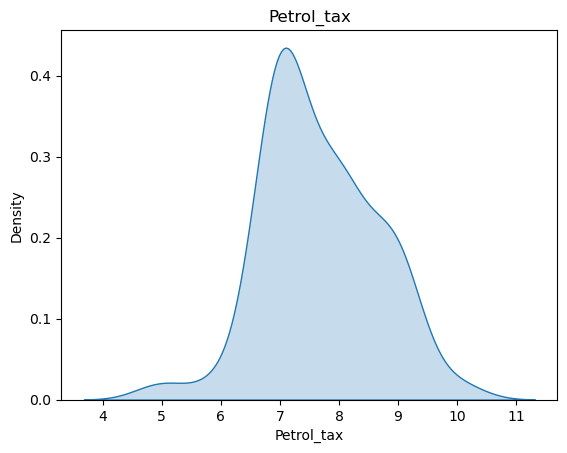

In [7]:
sb.kdeplot(df.Petrol_tax, fill=True)
plt.title("Petrol_tax")
plt.show()

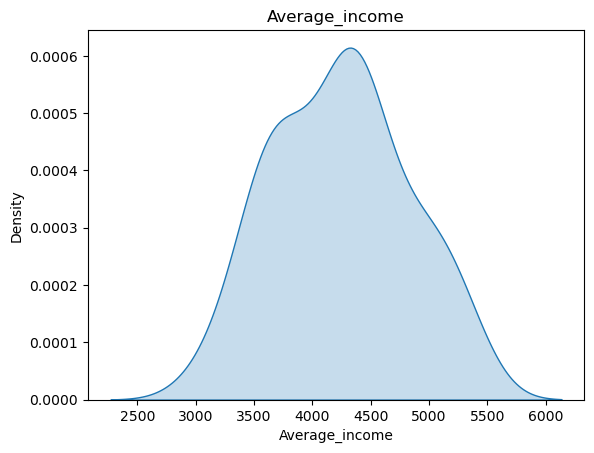

In [8]:
sb.kdeplot(df.Average_income, fill=True)
plt.title("Average_income")
plt.show()

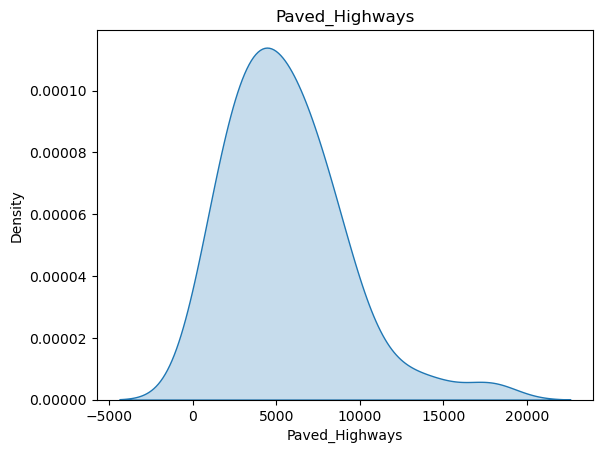

In [9]:
sb.kdeplot(df.Paved_Highways, fill=True)
plt.title("Paved_Highways")
plt.show()

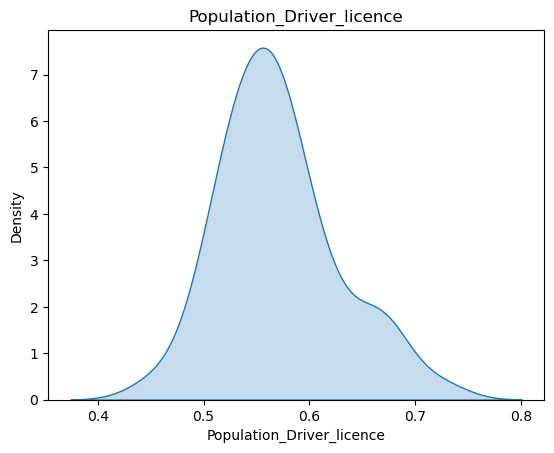

In [10]:
sb.kdeplot(df.Population_Driver_licence, fill=True)
plt.title("Population_Driver_licence")
plt.show()

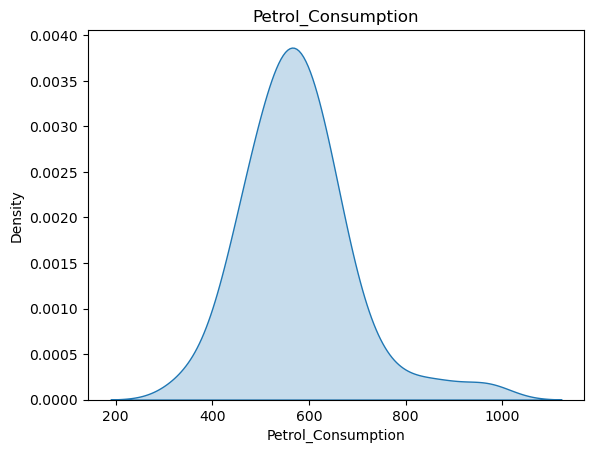

In [11]:
sb.kdeplot(df.Petrol_Consumption, fill=True)
plt.title("Petrol_Consumption")
plt.show()

## Outliers

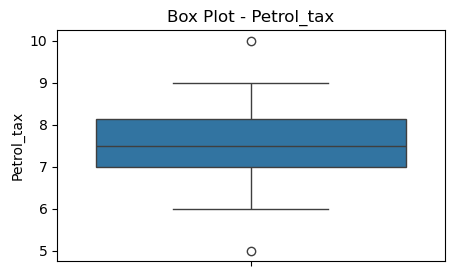

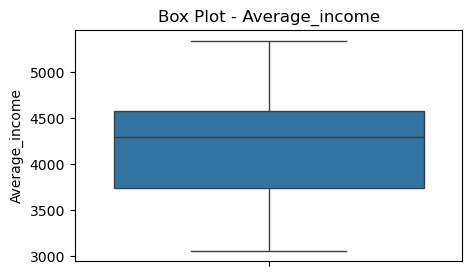

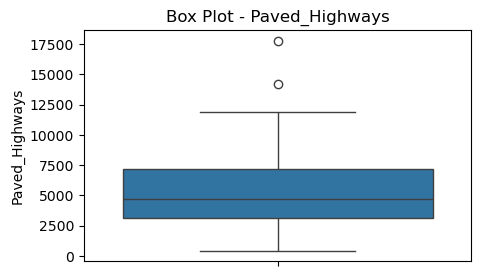

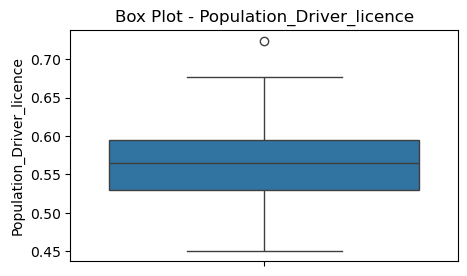

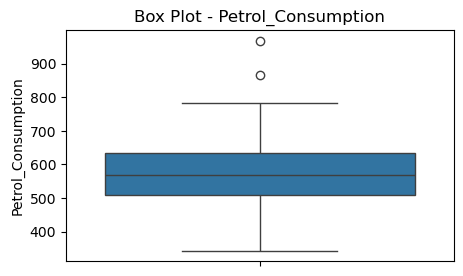

In [12]:
for col in df.columns:
    plt.figure(figsize=(5,3))
    sb.boxplot(y=df[col])
    plt.title(f"Box Plot - {col}")
    plt.show()

In [13]:
df_clean = df.copy()

for col in numeric.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

df_clean.shape

(42, 5)

## Statistical Metrics

In [14]:
# Standard Deviation
numeric.std()

Petrol_tax                      0.950770
Average_income                573.623768
Paved_Highways               3491.507166
Population_Driver_licence       0.055470
Petrol_Consumption            111.885816
dtype: float64

In [15]:
# Correlation
numeric.corr()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence,Petrol_Consumption
Petrol_tax,1.000000,0.012665,-0.522130,-0.288037,-0.451280
Average_income,0.012665,1.000000,0.050163,0.157070,-0.244862
Paved_Highways,-0.522130,0.050163,1.000000,-0.064129,0.019042
Population_Driver_licence,-0.288037,0.157070,-0.064129,1.000000,0.698965
Petrol_Consumption,-0.451280,-0.244862,0.019042,0.698965,1.000000


In [16]:
# Variance
numeric.var()

Petrol_tax                   9.039631e-01
Average_income               3.290442e+05
Paved_Highways               1.219062e+07
Population_Driver_licence    3.076950e-03
Petrol_Consumption           1.251844e+04
dtype: float64

In [17]:
# Percentiles
numeric.quantile([0.25,0.50,0.75])

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence,Petrol_Consumption
0.25,7.000,3739.00,3110.25,0.52975,509.50
0.50,7.500,4298.00,4735.50,0.56450,568.50
0.75,8.125,4578.75,7156.00,0.59525,632.75


## Statistical Graphs

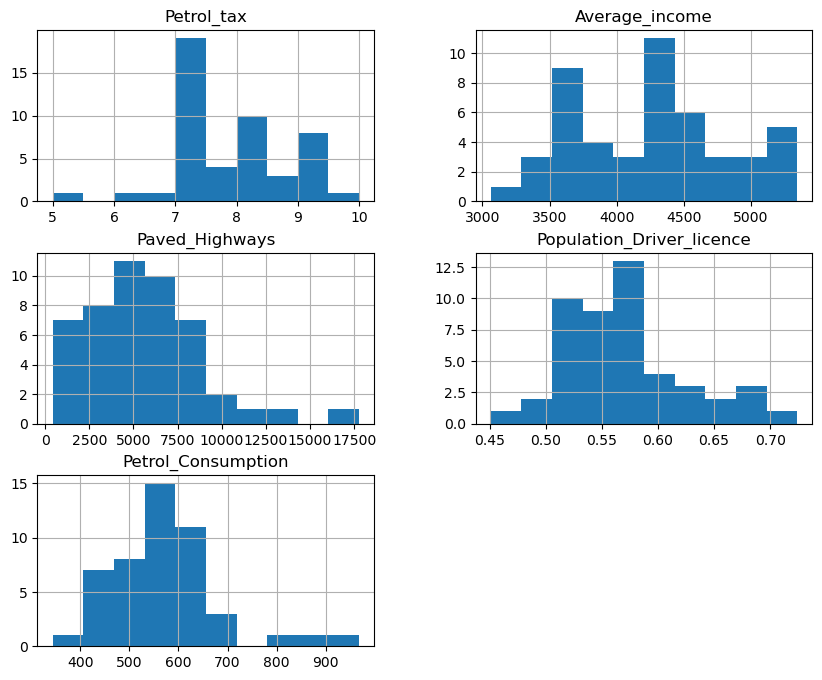

In [18]:
numeric.hist(figsize=(10,8))
plt.show()

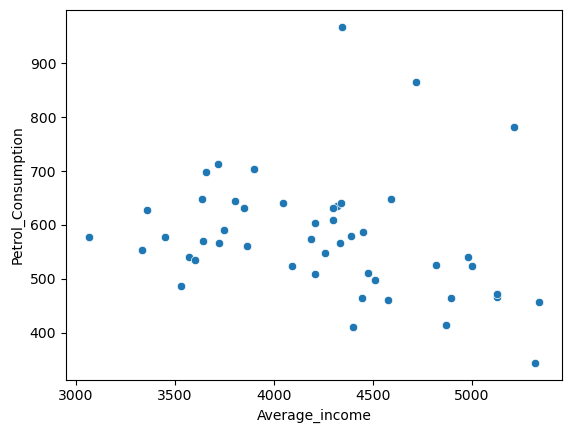

In [19]:
sb.scatterplot(data=df,x="Average_income",y="Petrol_Consumption")
plt.show()

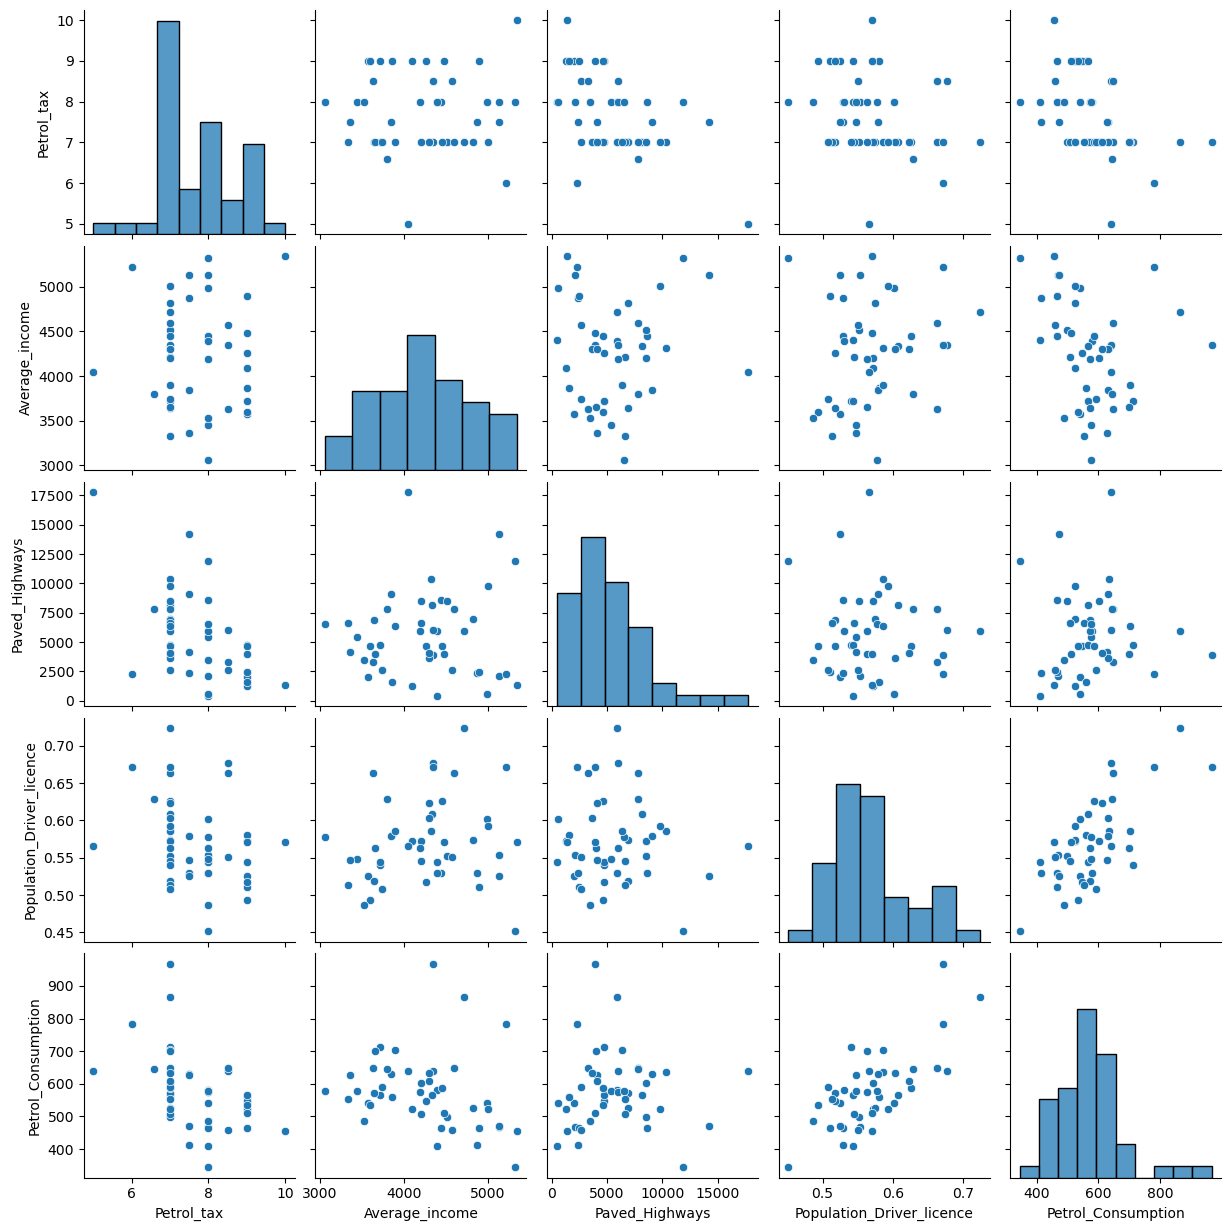

In [20]:
sb.pairplot(df)
plt.show()

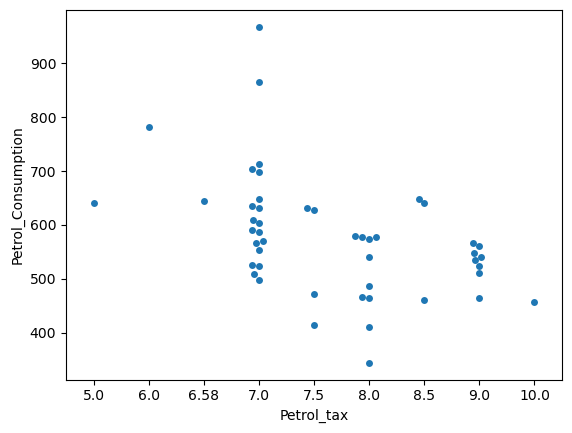

In [21]:
sb.swarmplot(
    x=df["Petrol_tax"],
    y=df["Petrol_Consumption"]
)

plt.show()

# CI

In [22]:
import numpy as np
from scipy.stats import t

# Smartphone Screen Time

In [25]:
a = [9.8, 10.3, 10.1, 9.9, 10.4,
        10.2, 9.7, 10.0, 10.5, 9.8,
        10.1, 9.9, 10.2, 10.3, 10.0,
        9.8, 10.4, 10.1, 9.9, 10.2]

In [26]:
mn = np.mean(a)
mn

np.float64(10.08)

In [27]:
sd = np.std(a)
sd

np.float64(0.22494443758403976)

In [28]:
n = 20
dof = n-1
dof

19

In [29]:
tscore = t.ppf(0.90,dof)
tscore

np.float64(1.3277282090267986)

In [30]:
moe = tscore * (sd/np.sqrt(n))
moe

np.float64(0.06678354107506682)

In [31]:
ci = mn - moe, mn + moe
ci

(np.float64(10.013216458924934), np.float64(10.146783541075067))

# Delivery Time

In [32]:
b = [29, 31, 30, 32, 28,
    29, 31, 30, 29, 32,
    30, 31, 28, 29, 30,
    31, 30, 29, 32, 28]

In [33]:
mn = np.mean(b)
mn

np.float64(29.95)

In [34]:
sd = np.std(b)
sd

np.float64(1.2835497652993437)

In [35]:
n = 20
dof = n-1
dof

19

In [36]:
tscore = t.ppf(0.95,dof)
tscore

np.float64(1.729132811521367)

In [37]:
moe = tscore * (sd/np.sqrt(n))
moe

np.float64(0.4962791911364988)

In [38]:
ci = mn - moe, mn + moe
ci

(np.float64(29.4537208088635), np.float64(30.446279191136497))

# Student Study Hours

In [39]:
c = [15, 16, 14, 17, 15,
    16, 15, 14, 17, 16,
    15, 16, 14, 15, 17,
    16, 15]

In [40]:
mn = np.mean(c)
mn

np.float64(15.470588235294118)

In [41]:
sd = np.std(c)
sd

np.float64(0.977249866225656)

In [42]:
n = 17
dof = n-1
dof

16

In [43]:
tscore = t.ppf(0.99,dof)
tscore

np.float64(2.583487185267472)

In [44]:
moe = tscore * (sd/np.sqrt(n))
moe

np.float64(0.6123327257278595)

In [45]:
ci = mn - moe, mn + moe
ci

(np.float64(14.85825550956626), np.float64(16.082920961021976))

# Hypothesis

### AutoDrive Components Ltd. – Engine Assembly Time Evaluation

In [46]:
import numpy as np
from scipy.stats import norm

In [47]:
# h0 = null
# h1 = alternate

In [48]:
tm = 1.8 + 0.02 * 450
m = 10.8
std = 25
sample = 35
alpha = 0.05

In [49]:
standard_error = std/np.sqrt(sample)
t_stats = (m - tm) / standard_error
t_stats

np.float64(0.0)

In [50]:
critical_value = norm.ppf(1-alpha)
critical_value

np.float64(1.6448536269514722)

In [51]:
if t_stats > critical_value:
    decision = 'H1'
else:
    decision = 'H0'


decision

'H0'

### FreshBake Foods Pvt. Ltd. – Baking Time Evaluation

In [52]:
# h0 = null
# h1 = alternate

In [53]:
tm = 10 + 0.08 * 75
m = 16.2
std = 6
sample = 30
alpha = 0.05

In [54]:
standard_error = std/np.sqrt(sample)
t_stats = (m - tm) / standard_error
t_stats

np.float64(0.18257418583505475)

In [55]:
critical_value = norm.ppf(1-alpha)
critical_value

np.float64(1.6448536269514722)

In [56]:
if t_stats > critical_value:
    decision = 'H1'
else:
    decision = 'H0'


decision

'H0'